In [1]:
### PRELUDE
import numpy as np
import sys
import matplotlib.pyplot as plt
from pathlib import Path

# Enable autoreload
%load_ext autoreload
%autoreload 2

# Add workspace to sys.path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
###

from src.seemps.analysis.mesh import RegularInterval
from src.seemps.analysis.expansion import GegenbauerExpansion, mps_polynomial_expansion

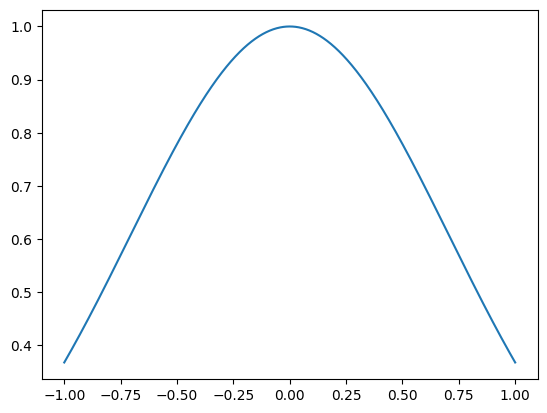

In [2]:
a, b = -1.0, 1.0
n = 10
N = 2**n
interval = RegularInterval(a, b, N, endpoint_right=True)

fn = lambda x: np.exp(-x**2)

x = interval.to_vector()
y = fn(x)

plt.plot(x, y)

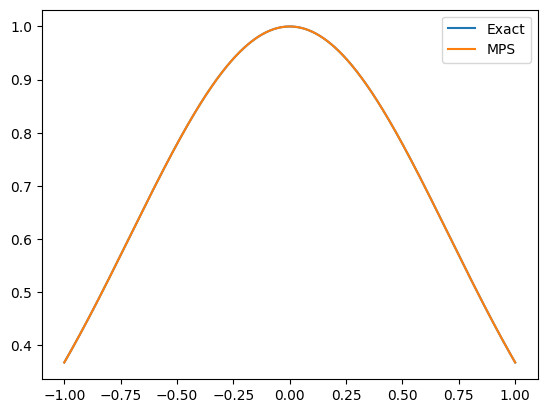

In [3]:
expansion = GegenbauerExpansion.project(fn, a, b, order=20, α=1.65)

# print(expansion.coeffs)
# new_coeffs = np.array([ 8.16975209e-01,  1.18986401e-17, -1.35374157e-01,  2.40778267e-17,
#   1.43572671e-02, -2.72772620e-17, -1.08379338e-03,  1.85469045e-17,
#   6.31931146e-05, -5.53434038e-17, -2.99648713e-06,  1.26515825e-17,
#   1.19638061e-07, -4.08172627e-17, -4.12336889e-09,  2.58127345e-17,
#   1.24986883e-10, -8.62303729e-17, -3.38127383e-12, -9.59974692e-17,])
# print(expansion.coeffs - new_coeffs)
# expansion.coeffs = new_coeffs

mps = mps_polynomial_expansion(expansion, interval, clenshaw=True)

y_mps = mps.to_vector()

plt.plot(x, y, label="Exact")
plt.plot(x, y_mps, label="MPS")
plt.legend()

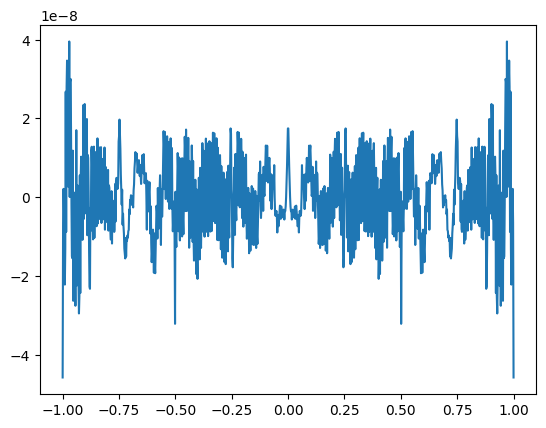

In [4]:
plt.plot(x, y-y_mps)